<a href="https://www.kaggle.com/code/siddhrajthakor/linear-regression-from-scratch?scriptVersionId=289105130" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Linear Regression From Scratch

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading our dataset

In [2]:
df=pd.read_csv('/kaggle/input/linear-regression-dataset-synthetic/Study_vs_Score_data.csv')
df.head()

,Attendance_Hours,Final_Marks
0,36.217808,58.997409
1,76.550001,71.598279
2,61.239576,72.520777
3,51.906094,69.005976
4,20.921305,53.259605


## basic EDA

In [3]:
df.shape # to know shape of the data

(1000, 2)

In [4]:
# To get basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Attendance_Hours  1000 non-null   float64
 1   Final_Marks       1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [5]:
# Statistical info about the data
df.describe()

,Attendance_Hours,Final_Marks
count,1000.000000,1000.000000
mean,44.317959,62.653458
std,20.449615,11.152260
min,10.324242,34.870813
25%,26.518129,53.755843
50%,44.776516,62.844569
75%,62.102371,71.520120
max,79.980237,91.061859


In [6]:
# Check for null values
df.isnull().sum()

Attendance_Hours    0
Final_Marks         0
dtype: int64

**which means there are no null values**

In [7]:
# Check for duplicated values
df.duplicated().sum()

np.int64(0)

**which means there are no duplicated values in it**

## Visual EDA

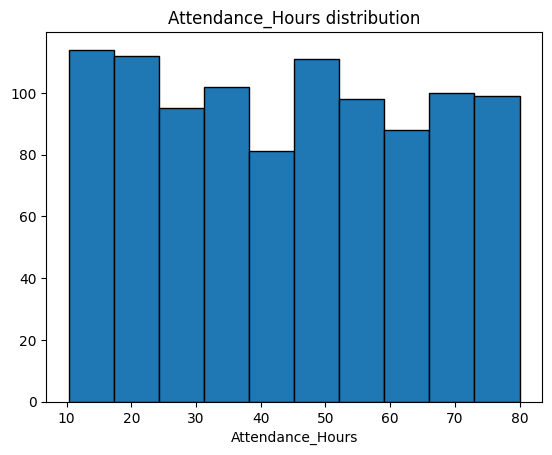

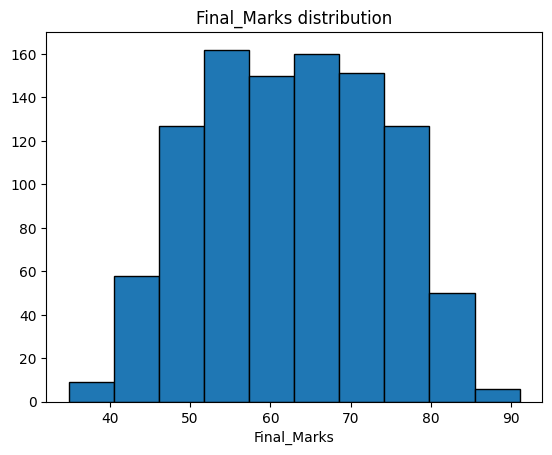

In [8]:
for i in df.columns:
    plt.hist(data=df,x=i,edgecolor='black')
    plt.xlabel(f'{i}')
    plt.title(f'{i} distribution')
    plt.show()

### Distribution Insights
**the distribution shows that attendance hours are fairely distributed but the marks are distributed between 50 to 80 marks**

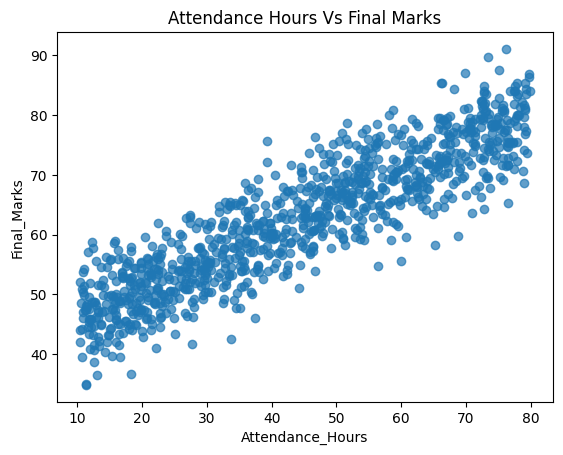

In [9]:
plt.scatter(x=df['Attendance_Hours'],y=df['Final_Marks'],alpha=0.7)
plt.title('Attendance Hours Vs Final Marks')
plt.xlabel('Attendance_Hours')
plt.ylabel('Final_Marks')
plt.show()

**which shows us linear relationship between the data points here**

## Modeling

### What is Linear Regression?

Linear Regression tries to draw the best straight line that explains the relationship between:

X → input / feature (e.g., hours studied)

y → output / target (e.g., marks)

The equation is:

> y=mx+b

m → slope (how much y changes when x changes)

b → intercept (value of y when x = 0)

In [10]:
# Simple Linear regression model
def simple_linear_regression(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Calculate slope (m)
    num = np.sum((x - x_mean) * (y - y_mean))
    den = np.sum((x - x_mean)**2)
    m = num / den
    
    # Calculate intercept (b)
    b = y_mean - m * x_mean
    
    return m, b

In [11]:
df.columns

Index(['Attendance_Hours', 'Final_Marks'], dtype='object')

In [12]:
m,b=simple_linear_regression(df['Attendance_Hours'],df['Final_Marks'])

In [13]:
m*56+b

np.float64(68.36532147099794)

In [14]:
y_pred = m * df['Attendance_Hours'] + b

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

print("R² Score:", r2_score(df['Final_Marks'], y_pred))
print("MSE:", mean_squared_error(df['Final_Marks'], y_pred))

R² Score: 0.8038270709726949
MSE: 24.37419704448645
